# Construcción de una capa de extracción de características basada en heurística

In [ ]:
#Montamos el notebook
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/TFG_Posdata/scripts/datasets/dataset_final.csv'
MODEL_PATH = '/content/drive/MyDrive/TFG_Posdata/models/lgbm_v1/'

#Imports
import pandas as pd
import numpy as np
import sklearn
import lightgbm as lgb
import joblib
import json
import re
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix as confussion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Obtenemos el dataframe desde el CSV que contiene el dataset
df = pd.read_csv(DATASET_PATH)

In [ ]:
#----------------MARCADORES HEURÍSTICOS A CONTEMPLAR----------------#

#Presencia de palabras de urgencia
urgency_words = ['urgente','urgently','urgent','inmediatamente','immediately',
                   'ahora','now','hoy','today','bloquea','blocked','suspendida',
                   'suspended','cancel','cancela','verifique','verify']

#Presencia de palabras de acción
action_words = ['haga clic','click','acceda','access','llame','call','responda',
                   'reply','confirme','confirm','descargue','download','ingrese','enter']

#Presencia de términos financieros
financial_words = ['cuenta','account','banco','bank','tarjeta','card','pago','payment',
                   'transferencia','transfer','bizum','credito','credit','débito','debit']

#Presencia de términos relacionados con premios
prize_words = ['gratis','free','premio','prize','ganador','winner','regalo','gift',
                   'oferta','offer','descuento','discount','gana','win']

#Presencia de palabras de amenaza
threat_words = ['amenaza', 'threat', 'peligro', 'danger', 'dangerous', 'peligroso', 'cuidado',
                'beware', 'attention', 'atencion', 'careful', 'cuidado']

#Patrón de URLs
_http_pattern = r"https?://[^\s]+"
_www_pattern = r"www\.[^\s]+"
url_pattern     = re.compile(f"({_http_pattern})|({_www_pattern})")

#Patrón de acortadores de URL
shortener_pattern = re.compile(r'\b(bit\.ly|t\.co|tinyurl\.com|goo\.gl|ow\.ly|rb\.gy|cutt\.ly)\b')

#Patrón de número de teléfono
phone_pattern   = re.compile(r'(\+?[1-9]\d{1,14}|[0-9]{9,15})')

#----------------FUNCIÓN DE EXTRACCION DE MARCADORES HEURÍSTICOS----------------#
def extract_features (df):
  numeric_df = pd.DataFrame()

  #Características estructurales
  numeric_df['text_len'] = df['text'].str.len()
  numeric_df['word_count'] = df['text'].str.split().str.len()
  numeric_df['avg_word_len'] = numeric_df['text_len'] / numeric_df['word_count'].replace(0, 1)
  numeric_df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper())/max(len(x), 1))
  numeric_df['digit_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit())/max(len(x), 1))
  numeric_df['excl_count'] = df['text'].str.count('!')
  numeric_df['ques_count'] = df['text'].str.count(r'\?')
  numeric_df['num_count'] = df['text'].str.count(r'\d')

  #características semánticas
  numeric_df['has_urgency'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in urgency_words))
  numeric_df['has_action'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in action_words))
  numeric_df['has_financial'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in financial_words))
  numeric_df['has_prize'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in prize_words))
  numeric_df['has_threat'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in threat_words))

  #Características de contenido
  numeric_df['has_url'] = df['text'].apply(lambda t: bool(url_pattern.search(str(t))))
  numeric_df['has_phone'] = df['text'].apply(lambda t: bool(phone_pattern.search(str(t))))
  numeric_df['url_len'] = df['text'].apply(lambda t: (m := url_pattern.search(str(t))) and len(m.group(0)) or 0)
  numeric_df['has_shortener'] = df['text'].apply(lambda t: bool(shortener_pattern.search(str(t))))

  return numeric_df

#Obtenemos las entradas (X) y salidas (y) del dataset que utilizar para el entrenamiento
X = extract_features(df)
y = (df['label'] == 'spam').astype(int)

#Dividimos el dataset en un conjunto de entrenamiento (train) y prueba (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Balanceamos los datos de prueba
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
#Inicializamos el modelo clasificador
model = lgb.LGBMClassifier()

#Entrenamos el modelo clasificador
model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.log_evaluation(period=50),
        lgb.early_stopping(stopping_rounds=50)
    ]
)


[LightGBM] [Info] Number of positive: 3826, number of negative: 3826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1167
[LightGBM] [Info] Number of data points in the train set: 7652, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.0884471
[100]	valid_0's binary_logloss: 0.0913182
Did not meet early stopping. Best iteration is:
[66]	valid_0's binary_logloss: 0.0865839


LGBMClassifier()

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       940
           1       0.93      0.92      0.93       211

    accuracy                           0.97      1151
   macro avg       0.96      0.95      0.95      1151
weighted avg       0.97      0.97      0.97      1151



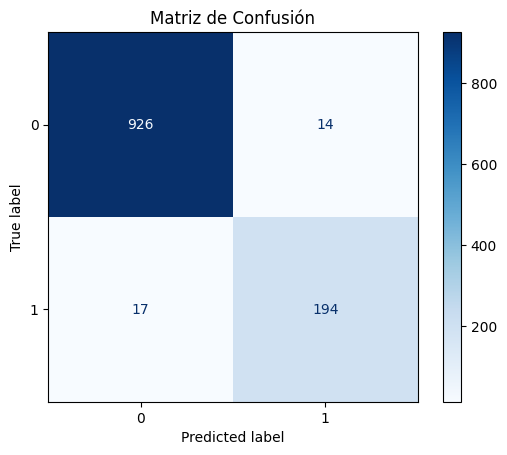

In [ ]:
#Evaluamos la eficacia del modelo probándolo sobre el conjunto de prueba
y_pred = model.predict(X_test)

#Imprimimos sus principales métricas
print(classification_report(y_test, y_pred))

#Imprimimos su matriz de confusión
cm = confussion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
#Guardamos el modelo y la configuración usada para entrenarlo

nombre_modelo = 'model.pkl'
with open(MODEL_PATH + nombre_modelo, 'wb') as f:
  joblib.dump(model, f)
print("Modelo guardado con éxito")

nombre_config = 'config.json'
config = {
    "threshold": 0.5,
    "features": X.columns.tolist(),
    "model_version": "lgbm_v1"
}
with open(MODEL_PATH + nombre_config, 'w') as f:
    json.dump(config, f)
print("Configuración guardada con éxito")

Modelo guardado con éxito
Configuración guardada con éxito
